In [28]:
from evoscape.jax.flax_models.landscape_flax import LandscapeFlax
from evoscape.jax.flax_models.autoencoder_flax import AutoEncoder

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax import nnx

from evoscape.landscapes import Landscape
from evoscape.modules import Node
from evoscape.morphogen_regimes import mr_const, mr_sigmoid
from evoscape.landscape_visuals import plot_traj, visualize_landscape, visualize_landscape_t
from evoscape.jax.dynamics import state_probs
from evoscape.jax.utils import get_drosophile_data, get_facs_data
from evoscape.jax.config import DATA_DIR
from evoscape.jax.losses import mmd_traj

plt.style.use("default")

## Creating the landscape and the autoencoder

Landscape with modules:
Node: x=-2.0; y=-1.5; a=[1.,1.]; s=[1.,1.]; tau=1.0,
Node: x=0.0; y=-1.5; a=[1.,1.]; s=[1.,1.]; tau=1.0,
Node: x=2.0; y=-1.5; a=[1.,1.]; s=[1.,1.]; tau=1.0,
Node: x=-2.0; y=1.5; a=[1.,1.]; s=[1.,1.]; tau=1.0,
Node: x=0.0; y=1.5; a=[1.,1.]; s=[1.,1.]; tau=1.0,
Node: x=2.0; y=1.5; a=[1.,1.]; s=[1.,1.]; tau=1.0


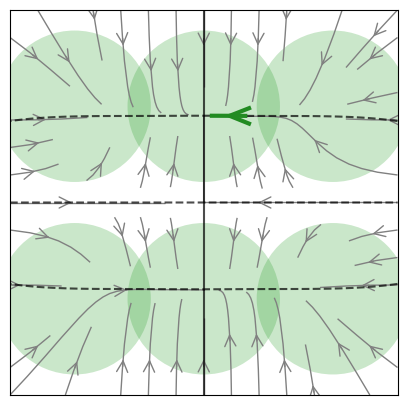

In [29]:
# modules = (
#     Node(x=1.5, y=0.0, a=np.array(1.5), s=np.array(1.0)),
#     Node(x=-2.5, y=0.0, a=np.array(1.5), s=np.array(1.0)),
# )

def create_module_grid(x, y):
    xx, yy = np.meshgrid(x,y)
    modules = [Node(x=x, y=y, a=np.array([1.0, 1.0]), s=np.array([1.0, 1.0]), tau=1.) for x,y in zip(xx.flatten(), yy.flatten())]
    return modules

x = [-2., 0., 2.]
y = [-1.5, 1.5]
modules = create_module_grid(x, y)

landscape = Landscape(
    module_list=modules,
    A0=0.05,
    init_cond=(0.0, 0.0),
    regime=mr_sigmoid,
    n_regimes=2,
    morphogen_times=(50.,),
)

print(landscape)

L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape_t(landscape, xx, yy, 2., color_scheme='fp_types', traj_times=(0., 20., 201), traj_init_cond=(2.,2.), traj_start=100)


In [30]:

# Initializing the landscape 
rngs = nnx.Rngs(0)
landscape_flax = LandscapeFlax(landscape, rngs)

landscape_flax.set_simulation(init_noise=0.2, t0=20.0, tf=200.0, nt=7, ndt=100, noise=0.2)
landscape_flax.set_regime_params(signal_param=None)
landscape_flax.set_state_probs(state_probs)

# Initialiazing the decoder
dims_encoder = [5,2]
dims_decoder = [2,4,5]

autoencoder = AutoEncoder(landscape_flax, dims_decoder=dims_decoder, dims_encoder=dims_encoder, rngs=rngs)

## Loading the data

In [31]:
filepath = DATA_DIR / "df_CHIR 2-3_clean.csv"

target_traj, timepoints = get_facs_data(filepath)

# there are too many cells, I only choose 200 of them randomly
indices = np.random.choice(target_traj.shape[1], size=200, replace=False)
target_traj = target_traj[:, indices, :]

print(target_traj.shape)
print(timepoints)


(5, 200, 7)
[2.  2.5 3.  3.5 4.  4.5 5. ]


In [32]:
q_init = target_traj[:, :, 0]
print(q_init.shape)

simulated_traj = autoencoder(q_init)
print(simulated_traj.shape)

loss = mmd_traj(simulated_traj, target_traj)
print(loss)

(5, 200)
(5, 200, 7)
5.4138374


(5, 200)
(2, 200)


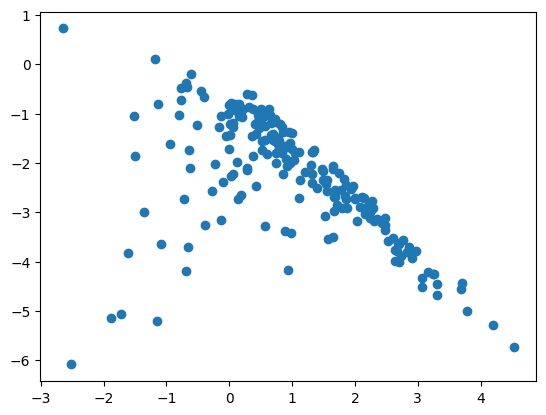

In [33]:
print(q_init.shape)
q_init_latent = nnx.vmap(lambda x : autoencoder.encoder(x), in_axes=1, out_axes=1)(q_init) # (2, n)

print(q_init_latent.shape)
plt.scatter(q_init_latent[0,:], q_init_latent[1,:])

## Training the model

Époque 0 | Loss: 27.9392
Époque 50 | Loss: 15.5363
Époque 100 | Loss: 10.8157
Époque 150 | Loss: 8.6994
Époque 200 | Loss: 7.2718
Époque 250 | Loss: 5.9794
Époque 300 | Loss: 4.9009
Époque 350 | Loss: 4.3393
Époque 400 | Loss: 4.0409
Époque 450 | Loss: 3.8792
Époque 500 | Loss: 3.8104
Époque 550 | Loss: 3.6823
Époque 600 | Loss: 3.6800
Époque 650 | Loss: 3.5428
Époque 700 | Loss: 4.0317
Époque 750 | Loss: 3.7687


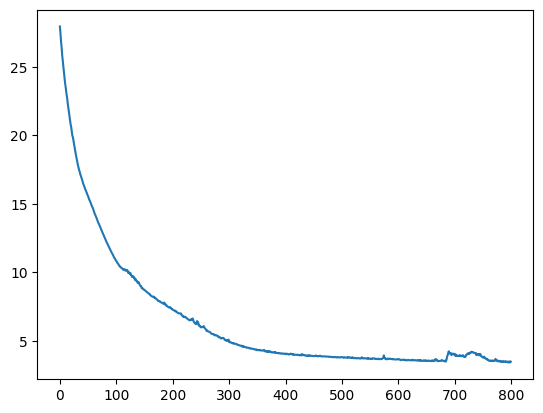

In [34]:
# Defining the optimizer 

optimizer = nnx.Optimizer(autoencoder, optax.adam(2e-3), wrt=nnx.Param)

# Defining the loss function, and the train_step 

def loss_fn(autoencoder, target_traj):
    # Forward pass
    q_init = target_traj[:,:,0]
    simulated_traj = autoencoder(q_init)

    # Loss on cloud points
    loss_dynamics = mmd_traj(simulated_traj, target_traj)

    # Loss on encoding the trajectory
    encoded_decoded_traj = autoencoder.forward_no_dynamics(target_traj)

    loss_encoding = jnp.sum((encoded_decoded_traj - target_traj)**2)
    
    return loss_dynamics + 1e-3*loss_encoding


@nnx.jit
def train_step(autoencoder, optimizer: nnx.Optimizer, target_traj):
    # nnx.value_and_grad computes the gradient with respect to the nnx.Params
    loss, grads = nnx.value_and_grad(loss_fn)(autoencoder, target_traj)
    
    optimizer.update(autoencoder, grads)
    
    return loss

# Training loop 
n_epochs = 800
loss_vals = []

for epoch in range(n_epochs):
    loss_val = train_step(autoencoder, optimizer, target_traj)
    
    if epoch%50 == 0:
        print(f"Époque {epoch} | Loss: {loss_val:.4f}")

    loss_vals.append(loss_val)

plt.plot(loss_vals)

Landscape with modules:
Node: x=-2.0964035987854004; y=-1.7878724336624146; a=[1.0721449,1.0686913]; s=[1.03183079,0.97382945]; tau=1.0,
Node: x=0.024263551458716393; y=-1.6717578172683716; a=[1.0191150,1.0168947]; s=[0.96711880,0.83956695]; tau=1.0,
Node: x=2.0974929332733154; y=-1.4748106002807617; a=[1.0039901,0.9742226]; s=[0.9794461,0.9844857]; tau=1.0,
Node: x=-2.144287347793579; y=1.524928092956543; a=[1.0125306,0.9946177]; s=[1.0215994,0.9052722]; tau=1.0,
Node: x=0.021977072581648827; y=1.6212124824523926; a=[0.8827274,0.7615302]; s=[0.91890389,0.81218684]; tau=1.0,
Node: x=2.1241021156311035; y=1.4771513938903809; a=[1.0342159,1.0600578]; s=[1.0193436,1.0081592]; tau=1.0


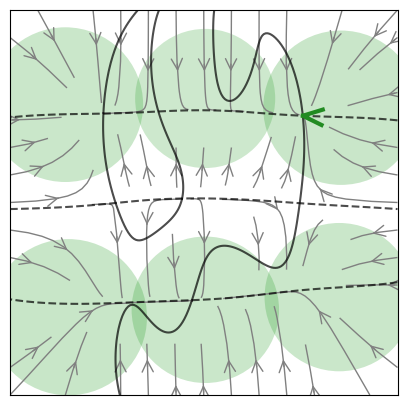

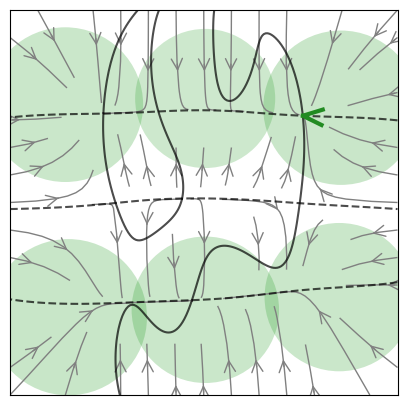

In [35]:
landscape = autoencoder.landscape_flax.get_landscape()

print(landscape)

L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape_t(landscape, xx, yy, 2., color_scheme='fp_types', traj_times=(0., 20., 201), traj_init_cond=(2.,2.), traj_start=100)
fig = visualize_landscape_t(landscape, xx, yy, 5., color_scheme='fp_types', traj_times=(0., 20., 201), traj_init_cond=(2.,2.), traj_start=100)

## Analyzing the model

(5, 200)
(2, 200)


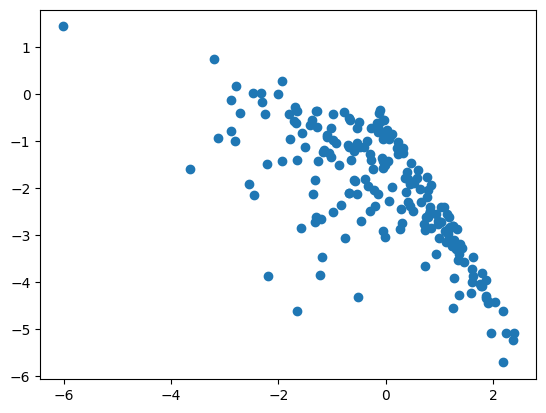

In [36]:
print(q_init.shape)
q_init_latent = nnx.vmap(lambda x : autoencoder.encoder(x), in_axes=1, out_axes=1)(q_init) # (2, n)

print(q_init_latent.shape)
plt.scatter(q_init_latent[0,:], q_init_latent[1,:])

(2, 200, 7)


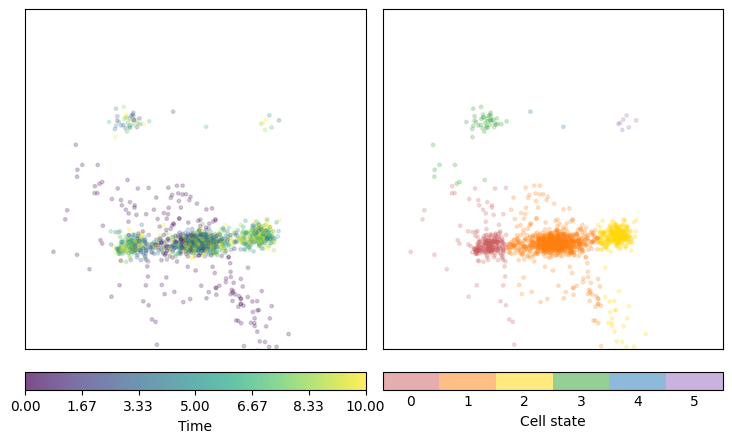

In [37]:
t0=0.0
tf=10.0
nt=7
traj, states = autoencoder.landscape_flax(q_init_latent)

print(traj.shape)

fig = plot_traj(traj, states, t0, tf, nt, L=4)